<a href="https://colab.research.google.com/github/anastasiakalyashova/python-ai-AnastasiaKalyashova/blob/main/week3c_elevation_heatmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ═══════════════════════════════════════════════════════
#  ЯЧЕЙКА 0. Подготовка данных (из week2b_read_csv.ipynb)
#  Запускать первой в каждом ноутбуке задания 3
# ═══════════════════════════════════════════════════════

# --- Параметры (изменять здесь) ----------------------
RADIUS_KM     = 300   # радиус соседства гор (для week3a)
TOP_N_ROCKS   = 10    # сколько топ-пород использовать
TOP_N_COMPLEX = 20    # сколько самых «сложных» гор брать
# -----------------------------------------------------

import os, pandas as pd, numpy as np
from itertools import combinations

# 1. Клонируем репозиторий (если ещё нет)
repo = "python-ai-AnastasiaKalyashova"
repo_path = f"/content/{repo}"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/anastasiakalyashova/python-ai-AnastasiaKalyashova.git
if os.getcwd() != repo_path:
    %cd {repo_path}

# 2. Читаем CSV
file_path = None
for root, dirs, files in os.walk("."):
    if "mountains.csv" in files:
        file_path = os.path.join(root, "mountains.csv")
        break
df = pd.read_csv(file_path)

# 3. Переименование столбцов
if "mountainLabel" in df.columns:
    df = df.rename(columns={
        "mountain":          "URL",
        "mountainLabel":     "mountain",
        "rockMaterialLabel": "rockMaterial",
        "elevationMeters":   "elevation",
    })

# 4. Нормализуем породы
df["rockMaterial"] = df["rockMaterial"].str.lower().str.strip()

# 🔧 ИСПРАВЛЕНИЕ: заменяем "lutite" на "пелит"
df["rockMaterial"] = df["rockMaterial"].replace("lutite", "пелит")

# 5. Парсим координаты
coords = df["coordinates"].str.extract(r'Point\(([^\s]+)\s+([^\s]+)\)')
df["lon"] = pd.to_numeric(coords[0], errors="coerce")
df["lat"] = pd.to_numeric(coords[1], errors="coerce")

# 6. df_unique — по одной строке на гору
df_unique = (
    df.groupby("URL")
    .agg(
        mountain   = ("mountain",     "first"),
        lon        = ("lon",          "first"),
        lat        = ("lat",          "first"),
        elevation  = ("elevation",    "first"),
        rock_count = ("rockMaterial", "nunique"),
        rocks      = ("rockMaterial", lambda x: list(x.unique())),
    )
    .reset_index()
)

# 7. df_clean — только физически возможные высоты
df_clean = df_unique[
    (df_unique.elevation >= 0) &
    (df_unique.elevation <= 8849)
].copy()

# 8. Топ пород по частоте (по df_clean)
top_rocks = (
    df[df["URL"].isin(df_clean["URL"])]
    ["rockMaterial"].value_counts()
    .head(TOP_N_ROCKS).index.tolist()
)

# 9. Co-occurrence матрица пород
pairs = []
for rocks in df_clean["rocks"]:
    clean = [r for r in rocks if r in top_rocks]
    pairs += list(combinations(sorted(set(clean)), 2))
cooc = (pd.DataFrame(pairs, columns=["r1", "r2"])
        .value_counts()
        .reset_index(name="count"))

print(f"✅ Длинный формат:    {len(df)} строк")
print(f"✅ Уникальных гор:    {len(df_unique)}")
print(f"✅ df_clean:          {len(df_clean)} гор (0–8849 м)")
print(f"✅ Топ-{TOP_N_ROCKS} пород:    {top_rocks}")
print(f"✅ Пар co-occurrence: {len(cooc)}")

/content/python-ai-AnastasiaKalyashova
✅ Длинный формат:    4431 строк
✅ Уникальных гор:    2915
✅ df_clean:          2914 гор (0–8849 м)
✅ Топ-10 пород:    ['известняк', 'песчаник', 'гранит', 'мергель', 'конгломерат', 'пелит', 'доломит', 'андезит', 'осадочная горная порода', 'базальт']
✅ Пар co-occurrence: 15


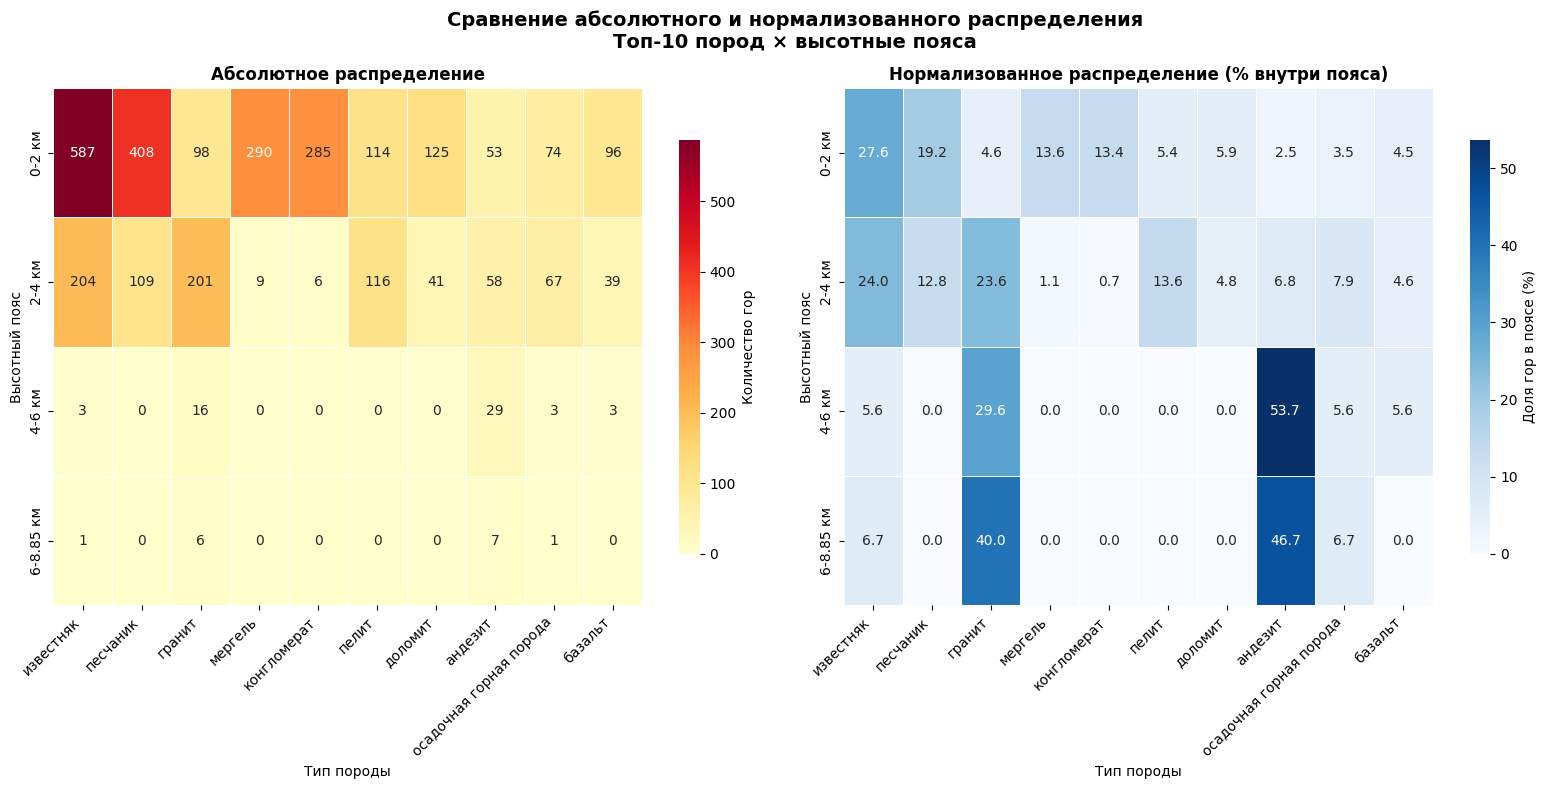

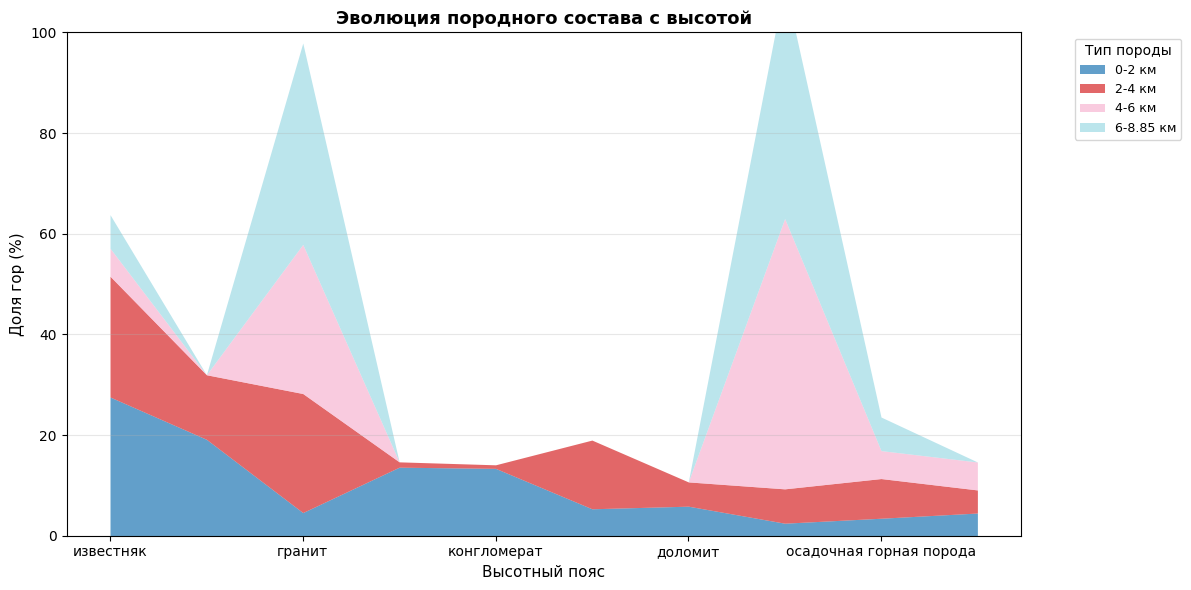


📊 АНАЛИЗ НОРМАЛИЗОВАННОГО РАСПРЕДЕЛЕНИЯ

📈 Какая порода доминирует в каждом высотном поясе?
   • 0-2 км: известняк (27.6%, 587 гор)
   • 2-4 км: известняк (24.0%, 204 гор)
   • 4-6 км: андезит (53.7%, 29 гор)
   • 6-8.85 км: андезит (46.7%, 7 гор)

🏔️ В каком поясе каждая порода встречается чаще всего?
   • известняк: 0-2 км (27.6% гор этого пояса)
   • песчаник: 0-2 км (19.2% гор этого пояса)
   • гранит: 6-8.85 км (40.0% гор этого пояса)
   • мергель: 0-2 км (13.6% гор этого пояса)
   • конгломерат: 0-2 км (13.4% гор этого пояса)
   • пелит: 2-4 км (13.6% гор этого пояса)
   • доломит: 0-2 км (5.9% гор этого пояса)
   • андезит: 4-6 км (53.7% гор этого пояса)
   • осадочная горная порода: 2-4 км (7.9% гор этого пояса)
   • базальт: 4-6 км (5.6% гор этого пояса)

📊 Общая статистика:
   • Всего ячеек: 40
   • Непустых ячеек: 29 (72.5%)
   • Среднее кол-во гор в непустой ячейке: nan

🏆 ТОП-3 ГОРЫ В КАЖДОМ ВЫСОТНОМ ПОЯСЕ

0-2 км:
   • Vojnik (1998 м)
   • Era Montanheta (Bossòst) (1993 

In [3]:
# ═══════════════════════════════════════════════════════
# week3c_elevation_heatmap_v3.ipynb — Нормализованный ковёр
# Показывает долю гор с каждой породой внутри высотного пояса
# ═══════════════════════════════════════════════════════

# Запусти сначала ячейку 0 (подготовка данных)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ═══════════════════════════════════════════════════════
# 1. ПОДГОТОВКА ДАННЫХ
# ═══════════════════════════════════════════════════════

elevation_bins = [0, 2000, 4000, 6000, 8850]
elevation_labels = ['0-2 км', '2-4 км', '4-6 км', '6-8.85 км']

df_heatmap = df_clean.copy()
df_heatmap['elevation_zone'] = pd.cut(
    df_heatmap['elevation'],
    bins=elevation_bins,
    labels=elevation_labels,
    right=False
)

# Фильтруем только горы, у которых есть хотя бы одна из топ-пород
df_heatmap = df_heatmap[df_heatmap['rocks'].apply(
    lambda x: any(rock in top_rocks for rock in x)
)]

# Создаём pivot таблицу с количеством гор
pivot_count = pd.DataFrame(0, index=elevation_labels, columns=top_rocks)

for zone in elevation_labels:
    zone_data = df_heatmap[df_heatmap['elevation_zone'] == zone]
    for rock in top_rocks:
        mask = zone_data['rocks'].apply(lambda x: rock in x)
        pivot_count.loc[zone, rock] = mask.sum()

# Нормализуем по строкам (внутри каждого высотного пояса)
# Добавляем маленькое число, чтобы избежать деления на ноль
row_sums = pivot_count.sum(axis=1)
row_sums = row_sums.replace(0, 1)  # Заменяем 0 на 1, чтобы избежать деления на ноль
pivot_normalized = pivot_count.div(row_sums, axis=0) * 100

# ═══════════════════════════════════════════════════════
# 2. ВИЗУАЛИЗАЦИЯ: ДВА ГРАФИКА РЯДОМ
# ═══════════════════════════════════════════════════════

# Создаём фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# График 1: Абсолютные значения
sns.heatmap(
    pivot_count,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    cbar_kws={'label': 'Количество гор', 'shrink': 0.8},
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title('Абсолютное распределение', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Тип породы', fontsize=10)
axes[0].set_ylabel('Высотный пояс', fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# График 2: Нормализованные значения (% внутри пояса)
sns.heatmap(
    pivot_normalized,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Доля гор в поясе (%)', 'shrink': 0.8},
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title('Нормализованное распределение (% внутри пояса)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Тип породы', fontsize=10)
axes[1].set_ylabel('Высотный пояс', fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.suptitle(
    f'Сравнение абсолютного и нормализованного распределения\n'
    f'Топ-{TOP_N_ROCKS} пород × высотные пояса',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# 3. ДОПОЛНИТЕЛЬНЫЙ ГРАФИК: ЭВОЛЮЦИЯ ПОРОД С ВЫСОТОЙ
# ═══════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 6))

# Транспонируем и строим стековую область
pivot_normalized.T.plot(
    kind='area',
    stacked=True,
    alpha=0.7,
    ax=ax,
    colormap='tab20',
    linewidth=0
)

ax.set_title('Эволюция породного состава с высотой', fontsize=13, fontweight='bold')
ax.set_xlabel('Высотный пояс', fontsize=11)
ax.set_ylabel('Доля гор (%)', fontsize=11)
ax.legend(title='Тип породы', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

# ═══════════════════════════════════════════════════════
# 4. СТАТИСТИКА И АНАЛИЗ
# ═══════════════════════════════════════════════════════

print("\n" + "="*60)
print("📊 АНАЛИЗ НОРМАЛИЗОВАННОГО РАСПРЕДЕЛЕНИЯ")
print("="*60)

print("\n📈 Какая порода доминирует в каждом высотном поясе?")
for zone in elevation_labels:
    dominant_rock = pivot_normalized.loc[zone].idxmax()
    dominant_pct = pivot_normalized.loc[zone, dominant_rock]
    count = pivot_count.loc[zone, dominant_rock]
    print(f"   • {zone}: {dominant_rock} ({dominant_pct:.1f}%, {int(count)} гор)")

print("\n🏔️ В каком поясе каждая порода встречается чаще всего?")
for rock in top_rocks:
    # Ищем пояс, где доля породы максимальна
    max_zone = pivot_normalized[rock].idxmax()
    max_pct = pivot_normalized.loc[max_zone, rock]
    if max_pct > 0:
        print(f"   • {rock}: {max_zone} ({max_pct:.1f}% гор этого пояса)")

print("\n📊 Общая статистика:")
total_cells = pivot_count.size
nonempty_cells = (pivot_count > 0).sum().sum()
print(f"   • Всего ячеек: {total_cells}")
print(f"   • Непустых ячеек: {nonempty_cells} ({nonempty_cells/total_cells*100:.1f}%)")
if nonempty_cells > 0:
    mean_nonempty = pivot_count[pivot_count > 0].values.mean()
    print(f"   • Среднее кол-во гор в непустой ячейке: {mean_nonempty:.1f}")

# ═══════════════════════════════════════════════════════
# 5. ТЕПЛОВАЯ КАРТА С ПОДПИСЯМИ (КАК В ПЕРВОМ ВАРИАНТЕ)
# ═══════════════════════════════════════════════════════

# Если хотите добавить подписи гор-чемпионов как в первом варианте
print("\n" + "="*60)
print("🏆 ТОП-3 ГОРЫ В КАЖДОМ ВЫСОТНОМ ПОЯСЕ")
print("="*60)

for zone in elevation_labels:
    zone_data = df_heatmap[df_heatmap['elevation_zone'] == zone]
    if len(zone_data) > 0:
        top_mountains = zone_data.nlargest(3, 'elevation')[['mountain', 'elevation']]
        print(f"\n{zone}:")
        for _, row in top_mountains.iterrows():
            print(f"   • {row['mountain']} ({row['elevation']:.0f} м)")